In [1]:
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, MaxPool2D, Flatten
import matplotlib.pyplot as plt
import os

# Print input file tree (optional, can be removed)
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))




2026-05-03 22:10:42.116827: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777846242.130454      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777846242.134620      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-03 22:10:42.153199: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/kaggle/input/train.csv.zip
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.zip
/kaggle/input/test_tfrecords.zip
/kaggle/input/train_tfrecords.zip
/kaggle/input/test_images.zip
/kaggle/input/train.csv
/kaggle/input/train.zip
/kaggle/input/description.md
/kaggle/input/train_images.zip
/kaggle/input/sample_submission.csv
/kaggle/input/label_num_to_disease_map.json
/kaggle/input/test_images/2574872277.jpg
/kaggle/input/test_images/1449210447.jpg
/kaggle/input/test_images/1269550303.jpg
/kaggle/input/test_images/1411799307.jpg
/kaggle/input/test_images/2474336811.jpg
/kaggle/input/test_images/2513489893.jpg
/kaggle/input/test_images/138763396.jpg
/kaggle/input/test_images/1454379342.jpg
/kaggle/input/test_images/135606795.jpg
/kaggle/input/test_images/244091101.jpg
/kaggle/input/test_images/1305931861.jpg
/kaggle/input/test_images/2431640165.jpg
/kaggle/input/test_images/262767997.jpg
/kaggle/input/test_images/2562280265.jpg
/kaggle/input/test_images/1249688756.jpg
/kaggle/input

(600, 800, 3)


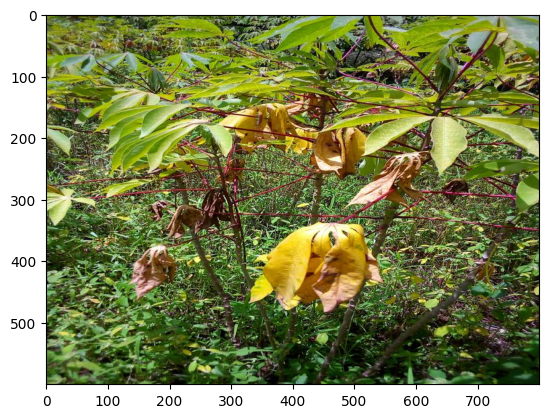

In [2]:
# Visual sanity‑check (not essential for training)
for f in os.listdir("../input/cassava-leaf-disease-classification/train_images")[
    1000:1001
]:
    img = cv2.imread(
        os.path.join("../input/cassava-leaf-disease-classification/train_images", f)
    )
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    print(img.shape)
    plt.show()
epochs = 10




In [3]:
def create_df(
    training_images=100,
    image_directory="../input/cassava-leaf-disease-classification/train_images",
    test_dir="../input/cassava-leaf-disease-classification/test_images",
):
    """
    Returns train and test dataframes.
    """
    train = pd.read_csv("../input/cassava-leaf-disease-classification/train.csv")
    labels = train["label"].tolist()
    labels = [[x] for x in labels]

    # --- train dataframe -------------------------------------------------
    im_paths = []
    for f in os.listdir(image_directory)[:training_images]:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            im_paths.append(os.path.join(image_directory, f))

    train_lis = list(zip(im_paths, labels))
    train_df = pd.DataFrame(train_lis, columns=["x_col", "y_col"])

    # --- test dataframe --------------------------------------------------
    test_paths = []
    for f in os.listdir(test_dir):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            test_paths.append(os.path.join(test_dir, f))

    test_df = pd.DataFrame(test_paths, columns=["x"])
    test_df["y"] = None
    return train_df, test_df


def hyper_model():
    """Unused hyper‑model; kept for compatibility."""
    model = tf.keras.applications.ResNet50V2(
        include_top=False, classes=5, input_shape=(128, 128, 3)
    )
    for layer in model.layers:
        layer.trainable = False
    flat = tf.keras.layers.Flatten()(model.output)
    out = Dense(5, activation="softmax")(flat)
    f_mod = tf.keras.Model(inputs=model.input, outputs=out)
    f_mod.compile(
        loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
    )
    return f_mod


def model1():
    """Simple ConvNet used for training."""
    model = Sequential()
    model.add(
        Conv2D(
            64,
            kernel_size=3,
            activation="relu",
            input_shape=(128, 128, 3),
            padding="same",
        )
    )
    model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(Conv2D(256, kernel_size=3, activation="relu", padding="same"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(Conv2D(512, kernel_size=3, activation="relu", padding="same"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(3, 3)))
    model.add(Conv2D(1024, kernel_size=3, activation="relu", padding="same"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(3, 3)))
    model.add(Flatten())
    model.add(Dense(512, activation="relu"))
    model.add(Dense(128, activation="relu"))
    model.add(Dense(5, activation="softmax"))
    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


def test_pre_process(
    dataframe, test_df, image_size=128, batch_size=64, valid_split=0.15
):
    """
    Build ImageDataGenerators for training/validation and test data.
    """
    im_dg = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1.0 / 255, validation_split=valid_split
    )

    te_dg = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)

    train_gen = im_dg.flow_from_dataframe(
        dataframe,
        x_col="x_col",
        y_col="y_col",
        class_mode="categorical",
        batch_size=batch_size,
        target_size=(image_size, image_size),
        subset="training",
        shuffle=True,
    )

    valid_gen = im_dg.flow_from_dataframe(
        dataframe,
        x_col="x_col",
        y_col="y_col",
        class_mode="categorical",
        batch_size=batch_size,
        target_size=(image_size, image_size),
        subset="validation",
        shuffle=True,
    )

    test_gen = te_dg.flow_from_dataframe(
        test_df,
        x_col="x",
        y_col=None,
        batch_size=batch_size,
        target_size=(image_size, image_size),
        class_mode=None,
        shuffle=False,
    )  # keep order consistent with test_df

    return train_gen, valid_gen, test_gen




In [4]:
model = model1()
model.summary()




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-03 22:10:49.130021: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777846249.130528      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:85:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 1024)   │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,726,021 (56.18 MB)

 Trainable params: 14,726,021 (56.18 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
train_df, test_df = create_df(training_images=90)
print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")




Train samples: 90
Test samples: 2676


In [6]:
train_gen, valid_gen, test_gen = test_pre_process(train_df, test_df)




Found 77 validated image filenames belonging to 5 classes.
Found 13 validated image filenames belonging to 5 classes.
Found 2676 validated image filenames.


In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)
history = model.fit(
    x=train_gen,
    epochs=epochs,
    verbose=2,
    callbacks=[early_stop],
    validation_data=valid_gen,
    shuffle=True,
)




/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1777846251.610156     113 service.cc:148] XLA service 0x7ff57c006de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777846251.610193     113 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-03 22:10:51.640646: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777846251.803665     113 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-05-03 22:10:53.683768: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_804', 440 bytes spill stores, 440 bytes spill loads

2026-05-03 22:10:54.139066: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_804', 448 bytes spill

2/2 - 17s - 8s/step - accuracy: 0.1429 - loss: 1.7634 - val_accuracy: 0.0769 - val_loss: 1.6126
Epoch 2/10
2/2 - 0s - 141ms/step - accuracy: 0.1169 - loss: 1.5658 - val_accuracy: 0.4615 - val_loss: 1.5895
Epoch 3/10
2/2 - 0s - 140ms/step - accuracy: 0.6104 - loss: 1.5665 - val_accuracy: 0.4615 - val_loss: 1.5240
Epoch 4/10
2/2 - 0s - 155ms/step - accuracy: 0.6104 - loss: 1.2932 - val_accuracy: 0.4615 - val_loss: 2.3442
Epoch 5/10
2/2 - 0s - 146ms/step - accuracy: 0.6104 - loss: 1.2684 - val_accuracy: 0.4615 - val_loss: 1.5170
Epoch 6/10
2/2 - 0s - 136ms/step - accuracy: 0.6104 - loss: 1.2364 - val_accuracy: 0.4615 - val_loss: 1.5032
Epoch 7/10
2/2 - 0s - 139ms/step - accuracy: 0.6104 - loss: 1.2982 - val_accuracy: 0.4615 - val_loss: 1.5135
Epoch 8/10
2/2 - 0s - 143ms/step - accuracy: 0.6104 - loss: 1.2094 - val_accuracy: 0.4615 - val_loss: 1.7601
Epoch 9/10
2/2 - 0s - 133ms/step - accuracy: 0.6104 - loss: 1.2185 - val_accuracy: 0.4615 - val_loss: 1.8744


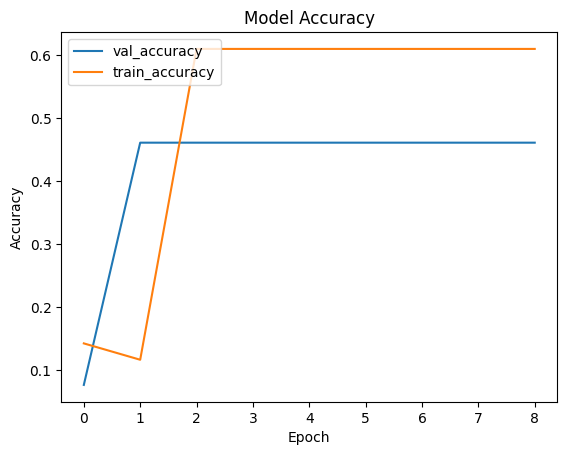

In [8]:
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="upper left")
plt.show()




In [9]:
pred = model.predict(test_gen, verbose=0)
label = np.argmax(pred, axis=1)

# Align predictions with original filenames (test_gen preserves order now)
image_ids = [os.path.basename(p) for p in test_df["x"].tolist()]

final_df = pd.DataFrame({"image_id": image_ids, "label": label})
final_df.to_csv("submission.csv", index=False)
print("Submission saved to submission.csv")

Submission saved to submission.csv
